In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
os.getcwd()
file = '../Scenario_Analysis_NEWEST.xlsx'
df = pd.read_excel(file, sheet_name='MethanolMarginal')
df = df.loc[:, ~df.columns.str.contains(r'\.\d+$')]
df = df.set_index(df.columns[0])

In [2]:
df

,Baseline,NoStorageCO2,NoStorageALL,H2,BioFixed,CO2Trans,ElectricityPrice
Week,,,,,,,
1,846.940788,848.561831,832.226435,846.940788,733.651247,857.647988,52.453952
2,839.548328,841.690978,694.294792,839.537984,731.340304,850.275226,55.661845
3,892.977851,898.588728,879.200746,893.207105,769.684743,903.685051,69.258333
4,904.096914,913.301418,972.484636,904.341659,782.892904,914.804114,74.586488
5,834.552993,833.112743,829.345935,834.552993,721.337387,845.260193,66.829524
6,718.567552,718.578697,709.871648,729.986747,602.733501,729.274752,51.007798
7,711.917172,712.375090,685.941339,727.338914,602.532111,722.548450,57.292917
8,713.451333,712.375090,715.189495,729.617571,602.733501,724.078591,55.870774
9,713.451333,714.967918,718.845514,728.680271,602.743061,724.078591,48.855714


In [3]:
import matplotlib.pyplot as plt

def plot_weekly_methanol(df, scenarios, scenario_colors=None):
    """
    df : weekly methanol marginal df (index = Week)
    scenarios : list of scenario names to plot on primary y-axis
    scenario_colors : optional dict mapping scenario -> color
    """

    if scenario_colors is None:
        scenario_colors = {}

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # --- Plot scenarios on primary axis ---
    for scen in scenarios:
        ax1.plot(
            df.index,
            df[scen],
            label=scen,
            linewidth=2,
            color=scenario_colors.get(scen, None)
        )

    ax1.set_xlabel("Week")
    ax1.set_ylabel("Methanol Dual Value (EUR/t)")
    ax1.set_title("Weekly Methanol Dual Value & Electricity Price")

    ax1.set_ylim(450,1150)

    # Grid behind lines
    ax1.grid(axis='y', linestyle='--', alpha=0.6)
    ax1.set_axisbelow(True)

    # --- Secondary axis for electricity price ---
    ax2 = ax1.twinx()
    ax2.plot(
        df.index,
        df["ElectricityPrice"],
        color="orange",
        linestyle="--",
        linewidth=2,
        label="Electricity Price"
    )
    ax2.set_ylim(0, 80)
    ax2.set_ylabel("Electricity Price (EUR/MWh)")

    # --- Combined legend (primary + secondary) ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=len(scenarios) + 1,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


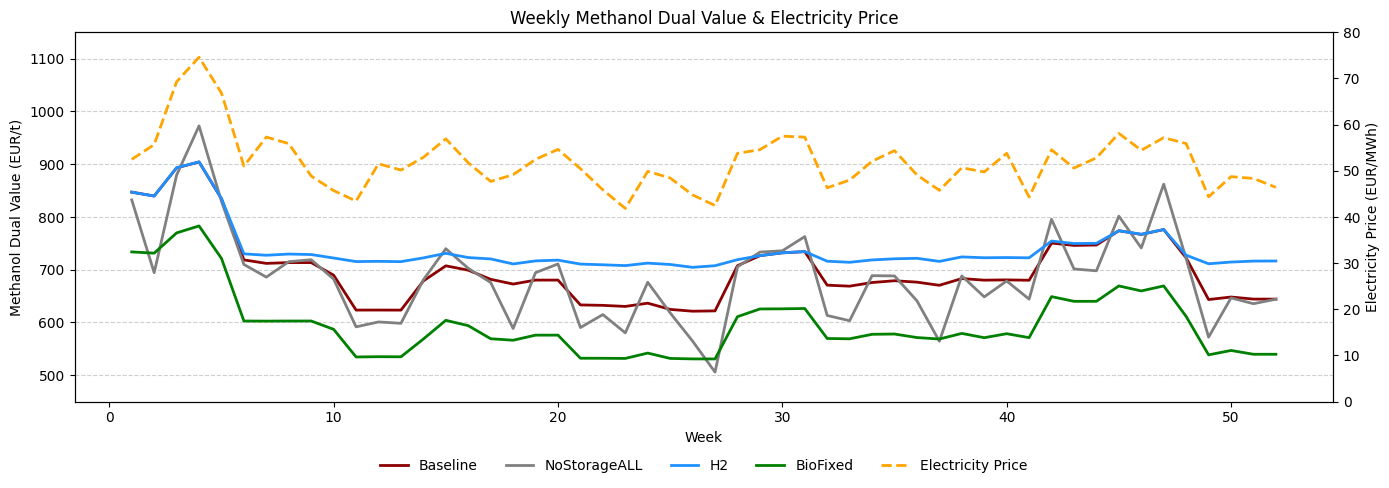

<Figure size 640x480 with 0 Axes>

In [4]:
scenario_colors = {
    "Baseline":  "darkred",
    "NoStorageCO2": "gold",
    "NoStorageALL": "gray",
    "H2":        "dodgerblue",
    "BioFixed":  "green",
    "CO2Trans": "purple"
}

all_scenarios = ["Baseline", "NoStorageCO2", "NoStorageALL", "H2", "BioFixed", "CO2Trans"]
scenarios = ["Baseline", "NoStorageALL", "H2", "BioFixed"]

plot_weekly_methanol(df, scenarios, scenario_colors)

plt.savefig("MethanolDualWeekly.pdf", format="pdf", bbox_inches="tight")

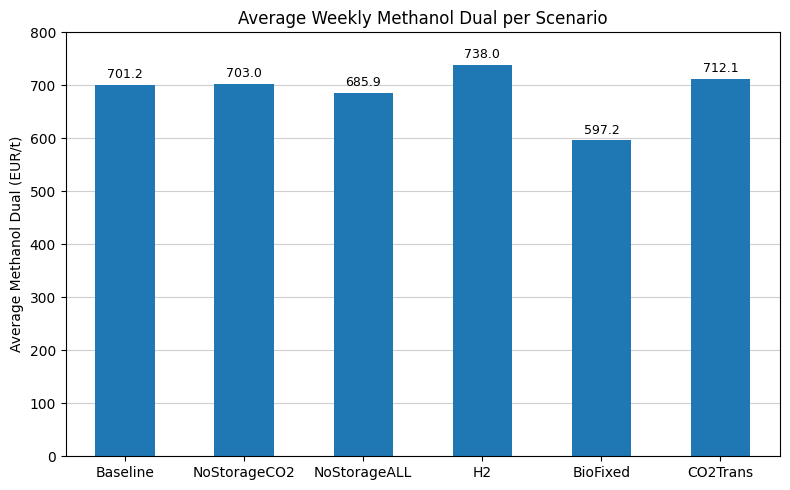

In [5]:
import matplotlib.pyplot as plt

# Select only scenario columns (exclude ElectricityPrice)
scenario_cols = [c for c in df.columns if c != "ElectricityPrice"]

# Compute averages
scenario_means = df[scenario_cols].mean()

fig, ax = plt.subplots(figsize=(8,5))

scenario_means.plot(kind='bar', ax=ax)

# Labels & title
ax.set_ylabel("Average Methanol Dual (EUR/t)")
ax.set_title("Average Weekly Methanol Dual per Scenario")

# Grid behind bars
ax.grid(axis='y', alpha=0.6)
ax.set_axisbelow(True)

# X & Y ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticks(range(0, int(scenario_means.max()) + 100, 100))

# Numeric labels on bars
for i, value in enumerate(scenario_means):
    ax.text(
        i,
        value + (value * 0.01),   # small offset above each bar
        f"{value:.1f}",           # one decimal place
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig("MethanolDualAverage.pdf", format="pdf", bbox_inches="tight")
plt.show()
